### Churn Modelling Case Study - Customer Churn Analysis

This notebook performs a comprehensive analysis of customer churn patterns in a banking dataset using descriptive statistics, probability distributions, and inferential statistics techniques.

In [292]:
# Import all required libraries
import scipy
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import os
from scipy.stats import *
from scipy.stats import norm, t, binom, poisson, expon


In [294]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [295]:
df = pd.read_csv('data/Churn_Modelling.csv')

---

#### Initial Data Exploration

Let's understand the structure and basic characteristics of our dataset.

In [296]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [297]:
print(f"{df.shape[0]} rows × {df.shape[1]} columns")

10000 rows × 14 columns


In [298]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [299]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [301]:
missing_values = df.isnull().sum()
missing_values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [322]:
print(list(df.columns))     # available cols

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


---

#### Data Cleaning and Preprocessing

Remove unnecessary columns and prepare data for analysis.

In [307]:
duplicates = df.duplicated().sum()
print(duplicates)

0


In [323]:
# drop unnecessary columns that don't contribute to analysis

df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(f"columns after cleanup: {list(df_clean.columns)}")

columns after cleanup: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [324]:
print(df_clean.dtypes)     # verify data types

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [326]:
df_analysis = df_clean.copy()
print(f"{df_analysis.shape}")

(10000, 11)


---

#### Exploratory Data Analysis (EDA)

Understanding overall churn distribution and patterns.

In [329]:
# Overall churn distribution
churn_counts = df_analysis['Exited'].value_counts()
print("Churn Distribution:")
print(f"Retained (0): {churn_counts[0]}")
print(f"Churned (1): {churn_counts[1]}")
print(f"\nChurn Rate: {(churn_counts[1] / len(df_analysis)) * 100:.2f}%")

Churn Distribution:
Retained (0): 7963
Churned (1): 2037

Churn Rate: 20.37%


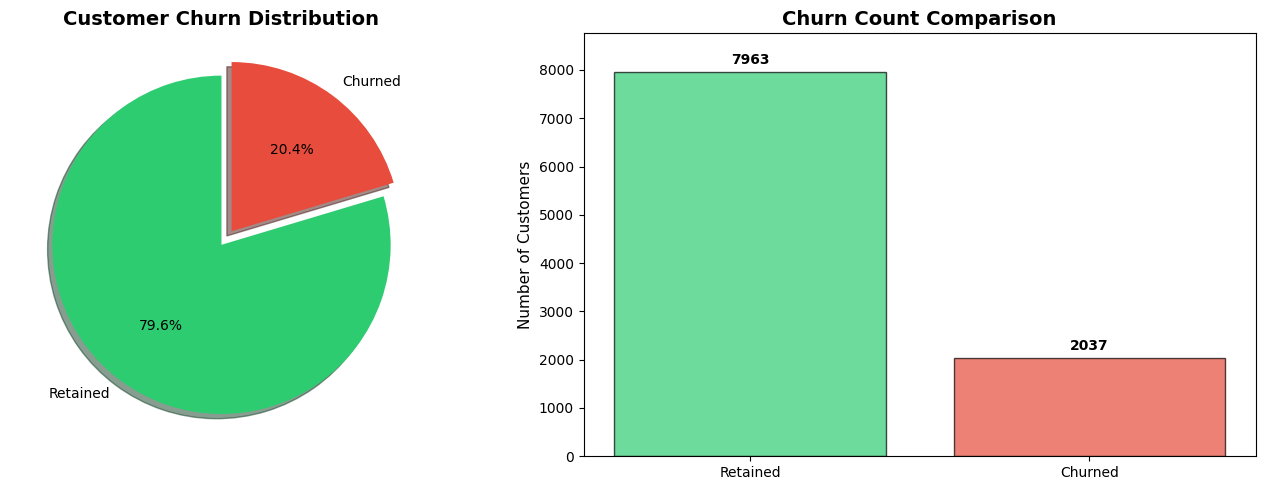

In [241]:
# Pie chart for churn distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
labels = ['Retained', 'Churned']
explode = (0, 0.1)

ax1.pie(churn_counts.values, labels=labels, autopct='%1.1f%%', 
        colors=colors, explode=explode, shadow=True, startangle=90)
ax1.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
ax2.bar(labels, churn_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax2.set_ylabel('Number of Customers', fontsize=11)
ax2.set_title('Churn Count Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(churn_counts.values) * 1.1)

# Add value labels on bars
for i, v in enumerate(churn_counts.values):
    ax2.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---

#### Categorical Variable Analysis

Analyzing churn patterns across categorical features.

In [242]:
# Churn analysis by Geography
geo_churn = pd.crosstab(df_analysis['Geography'], df_analysis['Exited'], normalize='index') * 100
print("Churn Rate by Geography (%):")
print(geo_churn)

Churn Rate by Geography (%):
Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


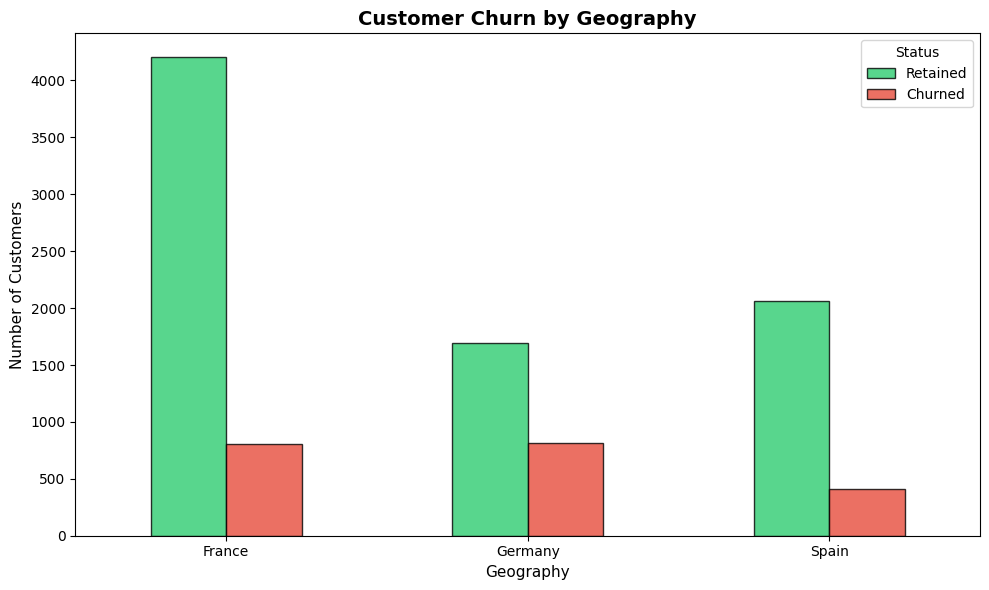

In [243]:
# Visualization: Geography vs Churn
geo_counts = pd.crosstab(df_analysis['Geography'], df_analysis['Exited'])

geo_counts.plot(kind='bar', figsize=(10, 6), color=['#2ecc71', '#e74c3c'], 
                edgecolor='black', alpha=0.8)
plt.title('Customer Churn by Geography', fontsize=14, fontweight='bold')
plt.xlabel('Geography', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'], title='Status')
plt.tight_layout()
plt.show()

In [244]:
# Churn analysis by Gender
gender_churn = pd.crosstab(df_analysis['Gender'], df_analysis['Exited'], normalize='index') * 100
print("Churn Rate by Gender (%):")
print(gender_churn)

Churn Rate by Gender (%):
Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928


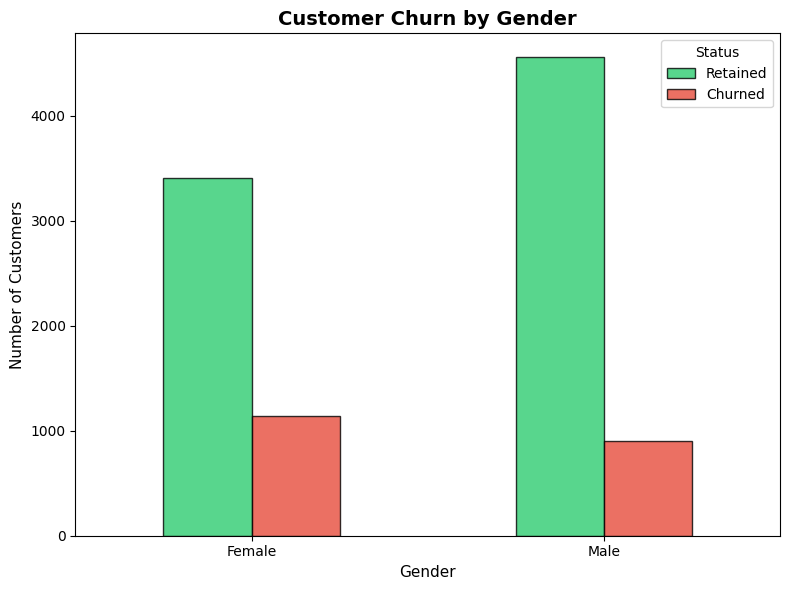

In [245]:
# Visualization: Gender vs Churn
gender_counts = pd.crosstab(df_analysis['Gender'], df_analysis['Exited'])

gender_counts.plot(kind='bar', figsize=(8, 6), color=['#2ecc71', '#e74c3c'], 
                   edgecolor='black', alpha=0.8)
plt.title('Customer Churn by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'], title='Status')
plt.tight_layout()
plt.show()

In [319]:
# Churn analysis by HasCrCard (Credit Card ownership)
card_churn = pd.crosstab(df_analysis['HasCrCard'], df_analysis['Exited'], normalize='index') * 100
print("Churn Rate by Credit Card Ownership (%):")
print(card_churn)

Churn Rate by Credit Card Ownership (%):
Exited             0          1
HasCrCard                      
0          79.185059  20.814941
1          79.815734  20.184266


In [247]:
# Churn analysis by IsActiveMember
active_churn = pd.crosstab(df_analysis['IsActiveMember'], df_analysis['Exited'], normalize='index') * 100
print("Churn Rate by Active Membership (%):")
print(active_churn)

Churn Rate by Active Membership (%):
Exited                  0          1
IsActiveMember                      
0               73.149103  26.850897
1               85.730926  14.269074


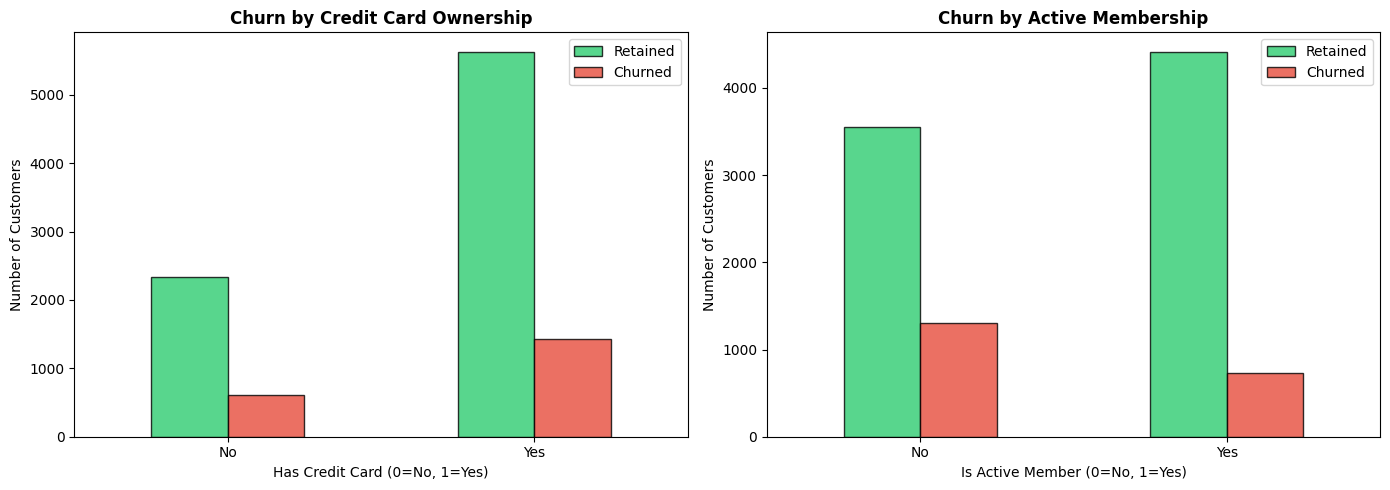

In [248]:
# Visualization: Active Member vs Churn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# HasCrCard
card_counts = pd.crosstab(df_analysis['HasCrCard'], df_analysis['Exited'])
card_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], 
                 edgecolor='black', alpha=0.8)
ax1.set_title('Churn by Credit Card Ownership', fontsize=12, fontweight='bold')
ax1.set_xlabel('Has Credit Card (0=No, 1=Yes)')
ax1.set_ylabel('Number of Customers')
ax1.set_xticklabels(['No', 'Yes'], rotation=0)
ax1.legend(['Retained', 'Churned'])

# IsActiveMember
active_counts = pd.crosstab(df_analysis['IsActiveMember'], df_analysis['Exited'])
active_counts.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], 
                   edgecolor='black', alpha=0.8)
ax2.set_title('Churn by Active Membership', fontsize=12, fontweight='bold')
ax2.set_xlabel('Is Active Member (0=No, 1=Yes)')
ax2.set_ylabel('Number of Customers')
ax2.set_xticklabels(['No', 'Yes'], rotation=0)
ax2.legend(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

In [249]:
# Churn analysis by Number of Products
products_churn = pd.crosstab(df_analysis['NumOfProducts'], df_analysis['Exited'], normalize='index') * 100
print("Churn Rate by Number of Products (%):")
print(products_churn)

Churn Rate by Number of Products (%):
Exited                 0           1
NumOfProducts                       
1              72.285602   27.714398
2              92.418301    7.581699
3              17.293233   82.706767
4               0.000000  100.000000


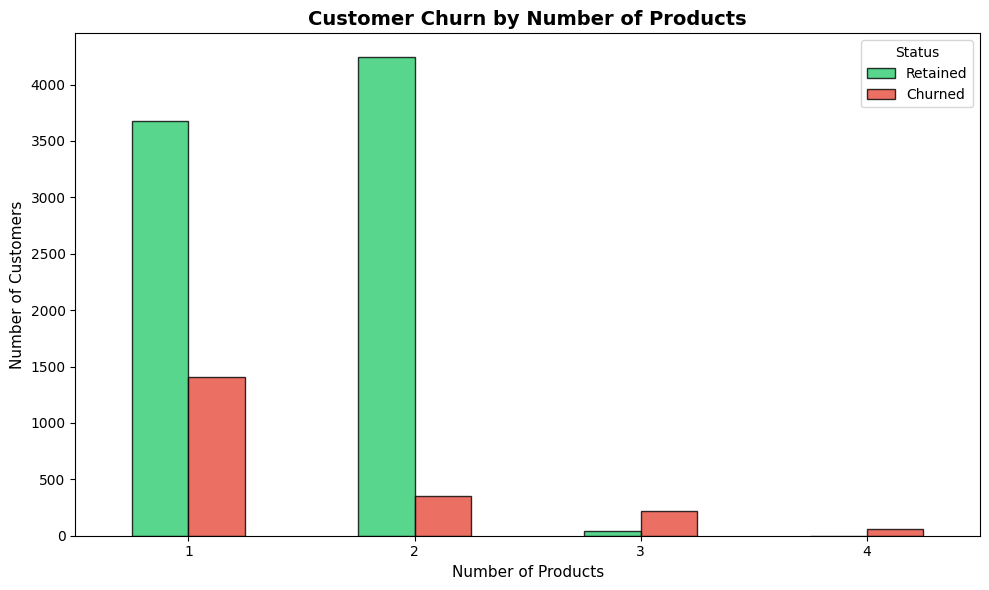

In [250]:
# Visualization: NumOfProducts vs Churn
products_counts = pd.crosstab(df_analysis['NumOfProducts'], df_analysis['Exited'])

products_counts.plot(kind='bar', figsize=(10, 6), color=['#2ecc71', '#e74c3c'], 
                     edgecolor='black', alpha=0.8)
plt.title('Customer Churn by Number of Products', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'], title='Status')
plt.tight_layout()
plt.show()

---

#### Numerical Variable Analysis

Analyzing numerical features and their relationship with churn using boxplots and quartile analysis.

In [251]:
# List of numerical columns to analyze
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Summary statistics for numerical variables by churn status
print("Summary Statistics by Churn Status:\n")
for col in numerical_cols:
    print(f"\n{col}:")
    print(df_analysis.groupby('Exited')[col].describe())

Summary Statistics by Churn Status:


CreditScore:
         count        mean         std    min    25%    50%    75%    max
Exited                                                                   
0       7963.0  651.853196   95.653837  405.0  585.0  653.0  718.0  850.0
1       2037.0  645.351497  100.321503  350.0  578.0  646.0  716.0  850.0

Age:
         count       mean        std   min   25%   50%   75%   max
Exited                                                            
0       7963.0  37.408389  10.125363  18.0  31.0  36.0  41.0  92.0
1       2037.0  44.837997   9.761562  18.0  38.0  45.0  51.0  84.0

Tenure:
         count      mean       std  min  25%  50%  75%   max
Exited                                                      
0       7963.0  5.033279  2.880658  0.0  3.0  5.0  7.0  10.0
1       2037.0  4.932744  2.936106  0.0  2.0  5.0  8.0  10.0

Balance:
         count          mean           std  min       25%        50%  \
Exited                                      

/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/36017398.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='CreditScore', data=df_analysis, palette=['#2ecc71', '#e74c3c'])


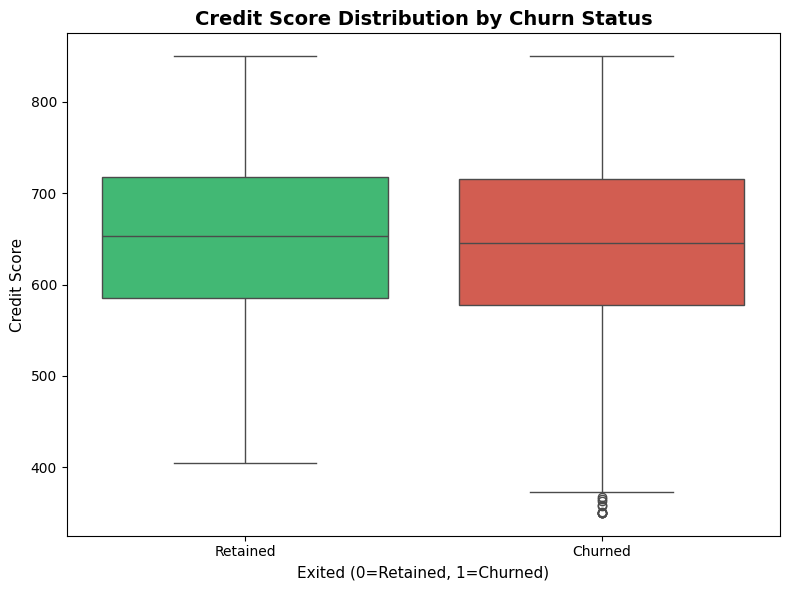

In [252]:
# Boxplot: CreditScore by Churn Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='CreditScore', data=df_analysis, palette=['#2ecc71', '#e74c3c'])
plt.title('Credit Score Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0=Retained, 1=Churned)', fontsize=11)
plt.ylabel('Credit Score', fontsize=11)
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.tight_layout()
plt.show()

In [253]:
# Calculate quartiles and IQR for CreditScore
q1_credit = np.percentile(df_analysis['CreditScore'], 25)
q2_credit = np.percentile(df_analysis['CreditScore'], 50)
q3_credit = np.percentile(df_analysis['CreditScore'], 75)
iqr_credit = q3_credit - q1_credit

print(f"CreditScore Quartile Analysis:")
print(f"Q1 (25th percentile): {q1_credit}")
print(f"Q2 (50th percentile - Median): {q2_credit}")
print(f"Q3 (75th percentile): {q3_credit}")
print(f"IQR: {iqr_credit}")

# Outlier bounds
upper_bound = q3_credit + 1.5 * iqr_credit
lower_bound = q1_credit - 1.5 * iqr_credit
print(f"\nOutlier bounds:")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Count outliers
outliers = df_analysis[(df_analysis['CreditScore'] > upper_bound) | 
                       (df_analysis['CreditScore'] < lower_bound)]
print(f"Number of outliers: {len(outliers)}")

CreditScore Quartile Analysis:
Q1 (25th percentile): 584.0
Q2 (50th percentile - Median): 652.0
Q3 (75th percentile): 718.0
IQR: 134.0

Outlier bounds:
Lower bound: 383.0
Upper bound: 919.0
Number of outliers: 15


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/269299655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df_analysis, palette=['#2ecc71', '#e74c3c'])


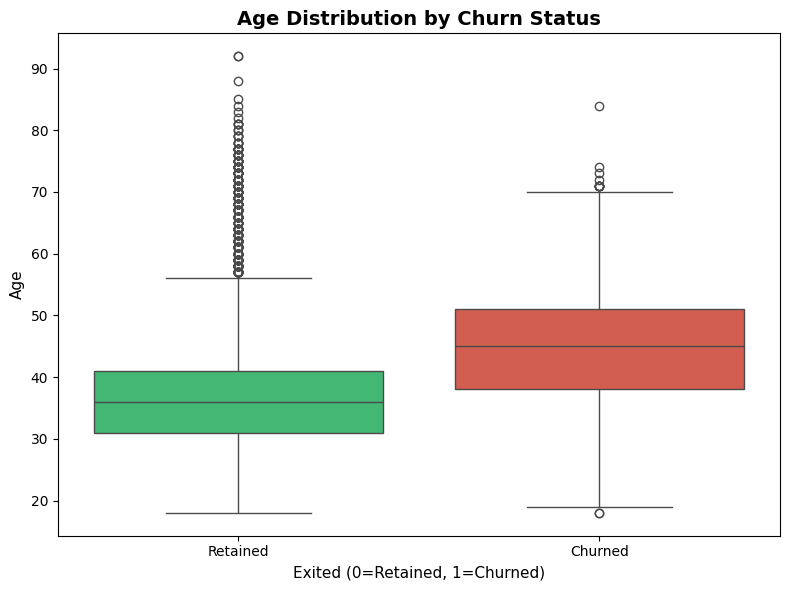

In [254]:
# Boxplot: Age by Churn Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='Age', data=df_analysis, palette=['#2ecc71', '#e74c3c'])
plt.title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0=Retained, 1=Churned)', fontsize=11)
plt.ylabel('Age', fontsize=11)
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.tight_layout()
plt.show()

In [255]:
# Age quartile analysis for churned customers
churned_age = df_analysis[df_analysis['Exited'] == 1]['Age']
retained_age = df_analysis[df_analysis['Exited'] == 0]['Age']

print("Age Analysis - Churned Customers:")
print(f"Mean: {churned_age.mean():.2f}")
print(f"Median: {churned_age.median():.2f}")
print(f"Q1: {np.percentile(churned_age, 25):.2f}")
print(f"Q3: {np.percentile(churned_age, 75):.2f}")

print("\nAge Analysis - Retained Customers:")
print(f"Mean: {retained_age.mean():.2f}")
print(f"Median: {retained_age.median():.2f}")
print(f"Q1: {np.percentile(retained_age, 25):.2f}")
print(f"Q3: {np.percentile(retained_age, 75):.2f}")

Age Analysis - Churned Customers:
Mean: 44.84
Median: 45.00
Q1: 38.00
Q3: 51.00

Age Analysis - Retained Customers:
Mean: 37.41
Median: 36.00
Q1: 31.00
Q3: 41.00


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/664711933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df_analysis, palette=['#2ecc71', '#e74c3c'])


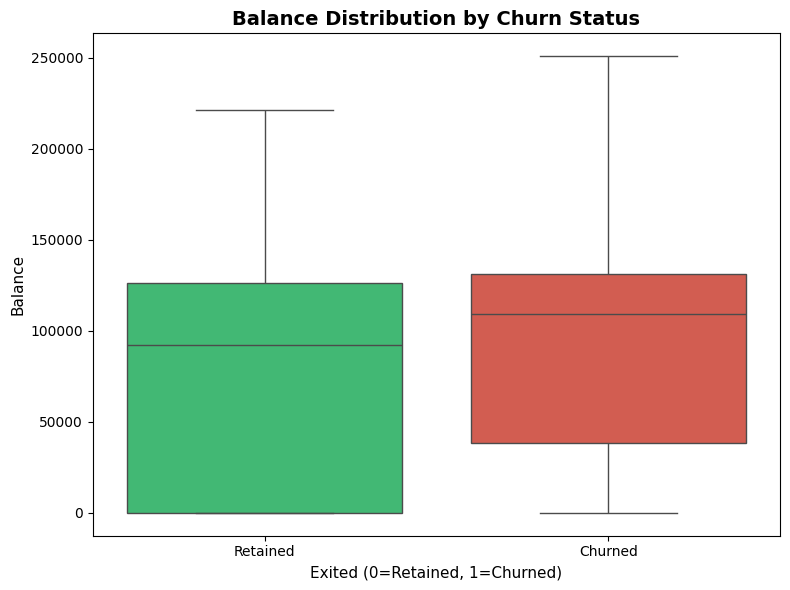

In [256]:
# Boxplot: Balance by Churn Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='Balance', data=df_analysis, palette=['#2ecc71', '#e74c3c'])
plt.title('Balance Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0=Retained, 1=Churned)', fontsize=11)
plt.ylabel('Balance', fontsize=11)
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.tight_layout()
plt.show()

/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/1316066999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Tenure', data=df_analysis, palette=['#2ecc71', '#e74c3c'])


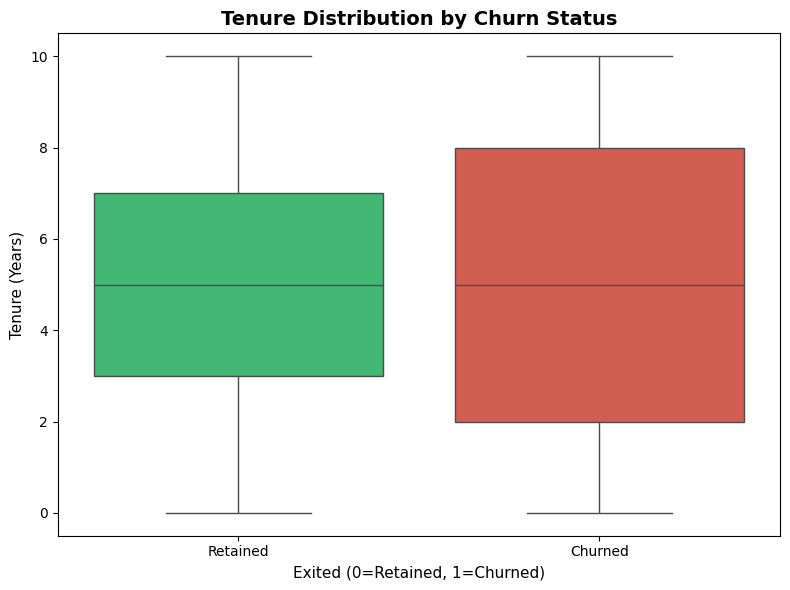

In [257]:
# Boxplot: Tenure by Churn Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='Tenure', data=df_analysis, palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0=Retained, 1=Churned)', fontsize=11)
plt.ylabel('Tenure (Years)', fontsize=11)
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.tight_layout()
plt.show()

/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/680731341.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='CreditScore', data=df_analysis,
/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/680731341.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Retained', 'Churned'])
/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/680731341.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df_analysis,
/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/680731341.py:14: UserWarning:

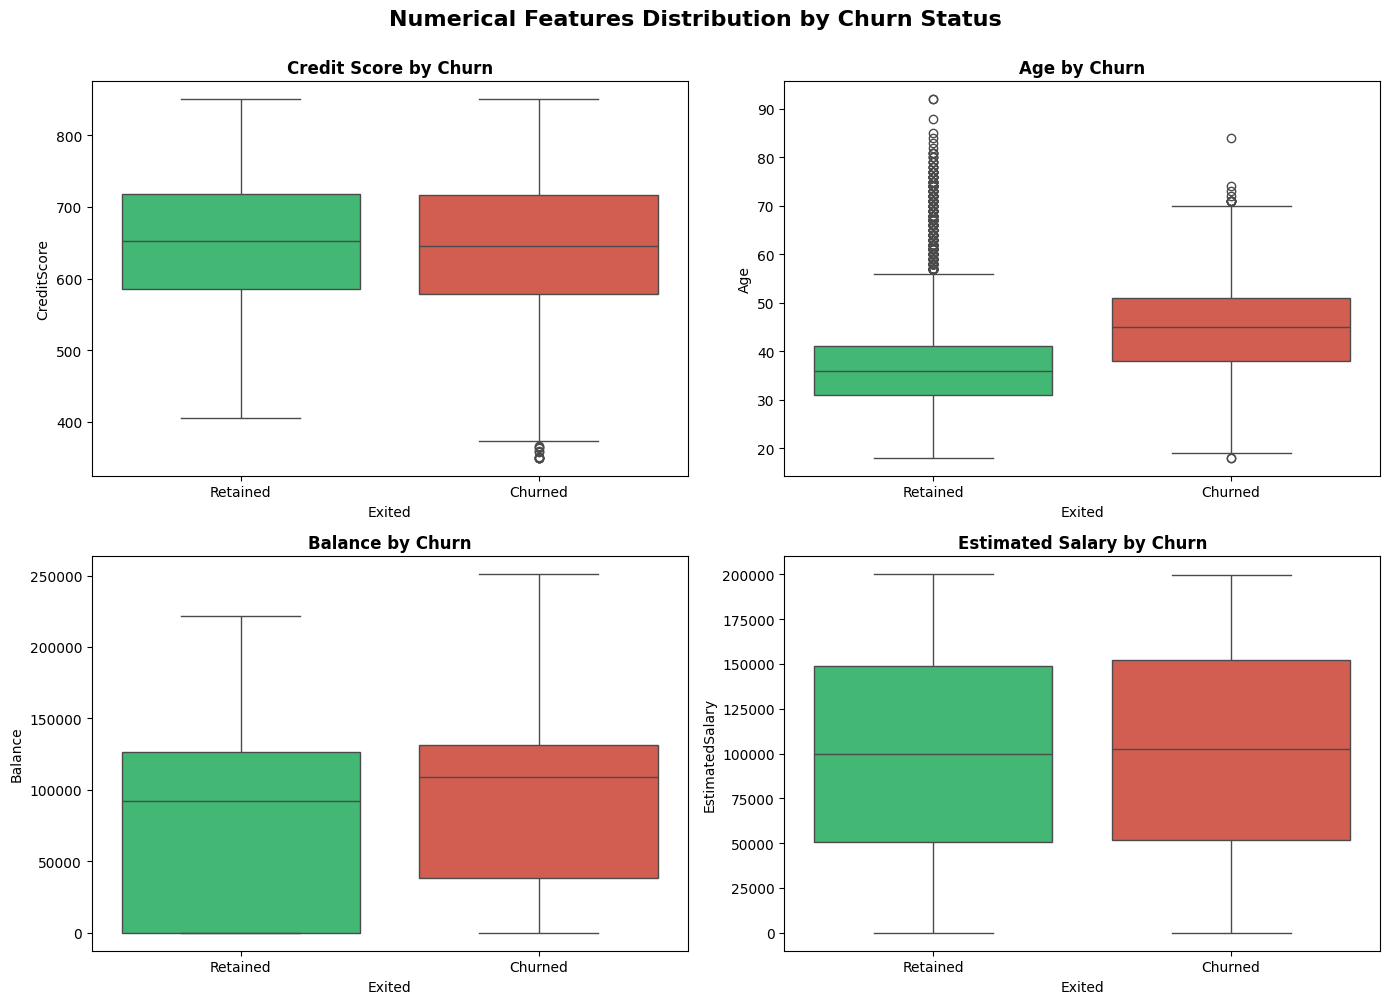

In [258]:
# Multiple boxplots in one figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CreditScore
sns.boxplot(x='Exited', y='CreditScore', data=df_analysis, 
            palette=['#2ecc71', '#e74c3c'], ax=axes[0, 0])
axes[0, 0].set_title('Credit Score by Churn', fontweight='bold')
axes[0, 0].set_xticklabels(['Retained', 'Churned'])

# Age
sns.boxplot(x='Exited', y='Age', data=df_analysis, 
            palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1])
axes[0, 1].set_title('Age by Churn', fontweight='bold')
axes[0, 1].set_xticklabels(['Retained', 'Churned'])

# Balance
sns.boxplot(x='Exited', y='Balance', data=df_analysis, 
            palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Balance by Churn', fontweight='bold')
axes[1, 0].set_xticklabels(['Retained', 'Churned'])

# EstimatedSalary
sns.boxplot(x='Exited', y='EstimatedSalary', data=df_analysis, 
            palette=['#2ecc71', '#e74c3c'], ax=axes[1, 1])
axes[1, 1].set_title('Estimated Salary by Churn', fontweight='bold')
axes[1, 1].set_xticklabels(['Retained', 'Churned'])

plt.suptitle('Numerical Features Distribution by Churn Status', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---

#### Distribution Analysis

Examining the shape and distribution characteristics of numerical variables.

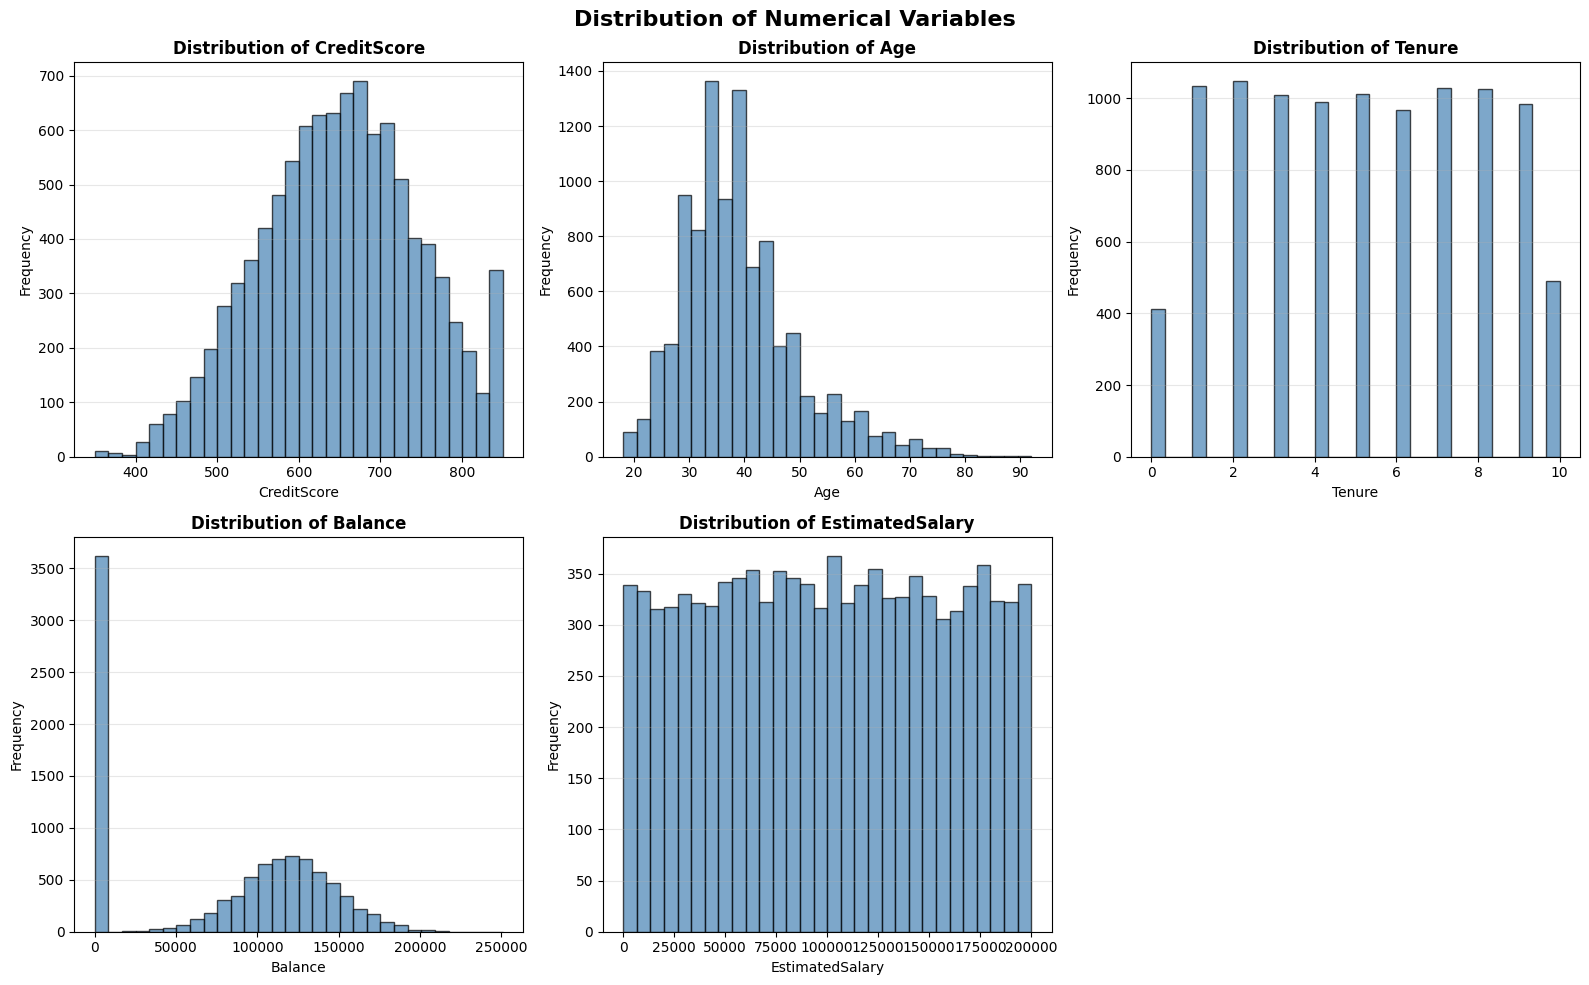

In [259]:
# Histograms for all numerical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df_analysis[col], bins=30, color='steelblue', 
                   edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [260]:
# Calculate skewness and kurtosis for all numerical variables
print("Skewness and Kurtosis Analysis:\n")
print(f"{'Variable':<20} {'Skewness':>12} {'Kurtosis':>12} {'Interpretation'}")
print("-" * 70)

for col in numerical_cols:
    # Remove NaN values and convert to numeric array
    clean_data = pd.to_numeric(df_analysis[col], errors='coerce').dropna()
    
    if len(clean_data) > 0:
        # Convert to numpy array to avoid transformation issues
        data_array = np.array(clean_data, dtype=float)
        
        # Calculate skewness and kurtosis (ensure they return scalars)
        skew_val = float(scipy.stats.skew(data_array))
        kurt_val = float(scipy.stats.kurtosis(data_array))
        
        # Skewness interpretation using np.abs to avoid scipy transformation
        if np.abs(skew_val) < 0.5:
            skew_interp = "Fairly symmetric"
        elif skew_val > 0:
            skew_interp = "Right-skewed"
        else:
            skew_interp = "Left-skewed"
        
        print(f"{col:<20} {skew_val:>12.4f} {kurt_val:>12.4f} {skew_interp}")
    else:
        print(f"{col:<20} {'N/A':>12} {'N/A':>12} No valid data")

Skewness and Kurtosis Analysis:

Variable                 Skewness     Kurtosis Interpretation
----------------------------------------------------------------------
CreditScore               -0.0716      -0.4261 Fairly symmetric
Age                        1.0112       1.3940 Right-skewed
Tenure                     0.0110      -1.1652 Fairly symmetric
Balance                   -0.1411      -1.4893 Fairly symmetric
EstimatedSalary            0.0021      -1.1815 Fairly symmetric


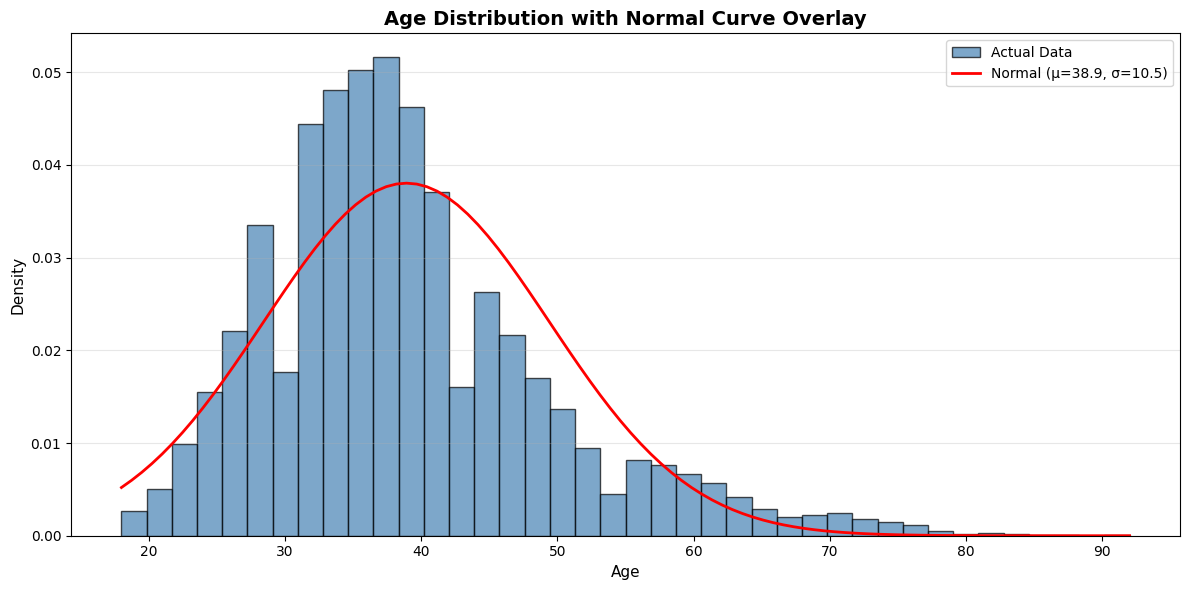

Age: Mean = 38.92, Std Dev = 10.49
Skewness = 1.0112


In [261]:
# Age distribution with overlay of normal curve
plt.figure(figsize=(12, 6))

# Histogram
plt.hist(df_analysis['Age'], bins=40, density=True, alpha=0.7, 
         color='steelblue', edgecolor='black', label='Actual Data')

# Fit normal distribution
mu, sigma = df_analysis['Age'].mean(), df_analysis['Age'].std()
x = np.linspace(df_analysis['Age'].min(), df_analysis['Age'].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, 
         label=f'Normal (μ={mu:.1f}, σ={sigma:.1f})')

plt.title('Age Distribution with Normal Curve Overlay', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Age: Mean = {mu:.2f}, Std Dev = {sigma:.2f}")
print(f"Skewness = {scipy.stats.skew(df_analysis['Age']):.4f}")

Balance Analysis:
Customers with zero balance: 3617 (36.17%)
Customers with positive balance: 6383 (63.83%)


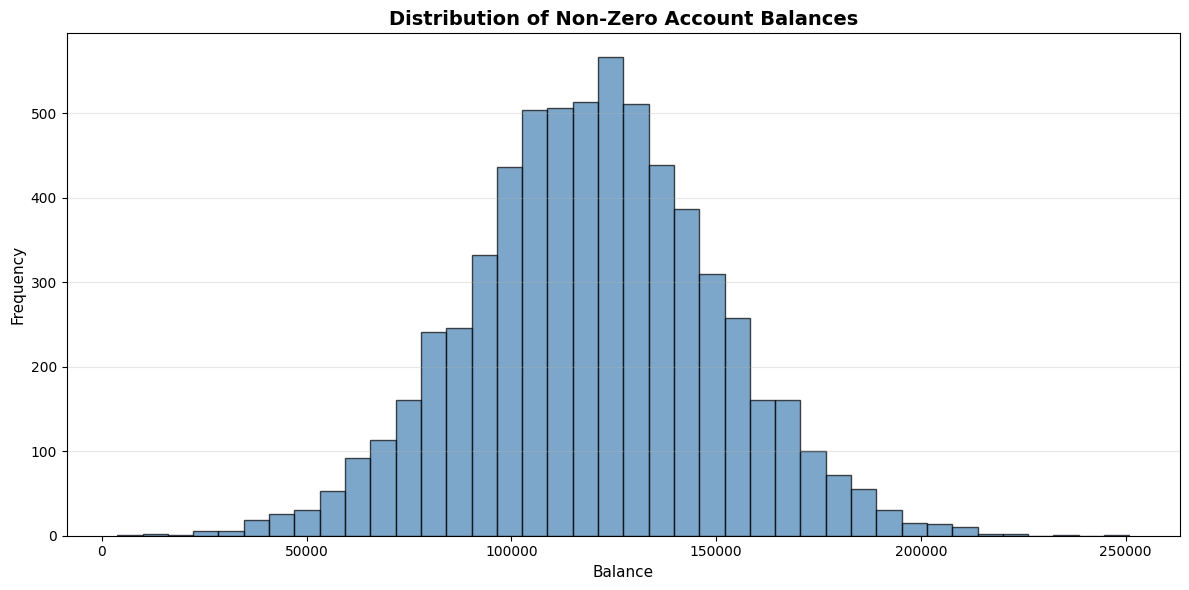

In [262]:
# Balance distribution analysis
# Note: Balance has many zero values (customers with no balance)
zero_balance = (df_analysis['Balance'] == 0).sum()
total_customers = len(df_analysis)

print(f"Balance Analysis:")
print(f"Customers with zero balance: {zero_balance} ({zero_balance/total_customers*100:.2f}%)")
print(f"Customers with positive balance: {total_customers - zero_balance} ({(total_customers - zero_balance)/total_customers*100:.2f}%)")

# Histogram for non-zero balances
non_zero_balance = df_analysis[df_analysis['Balance'] > 0]['Balance']

plt.figure(figsize=(12, 6))
plt.hist(non_zero_balance, bins=40, color='steelblue', 
         edgecolor='black', alpha=0.7)
plt.title('Distribution of Non-Zero Account Balances', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

#### Correlation Analysis

Examining relationships between variables and their correlation with churn.

In [263]:
# Select numerical columns for correlation analysis
corr_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 
                'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
                'EstimatedSalary', 'Exited']

correlation_matrix = df_analysis[corr_columns].corr()

print("Correlation with Exited (Churn):")
print(correlation_matrix['Exited'].sort_values(ascending=False))

Correlation with Exited (Churn):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


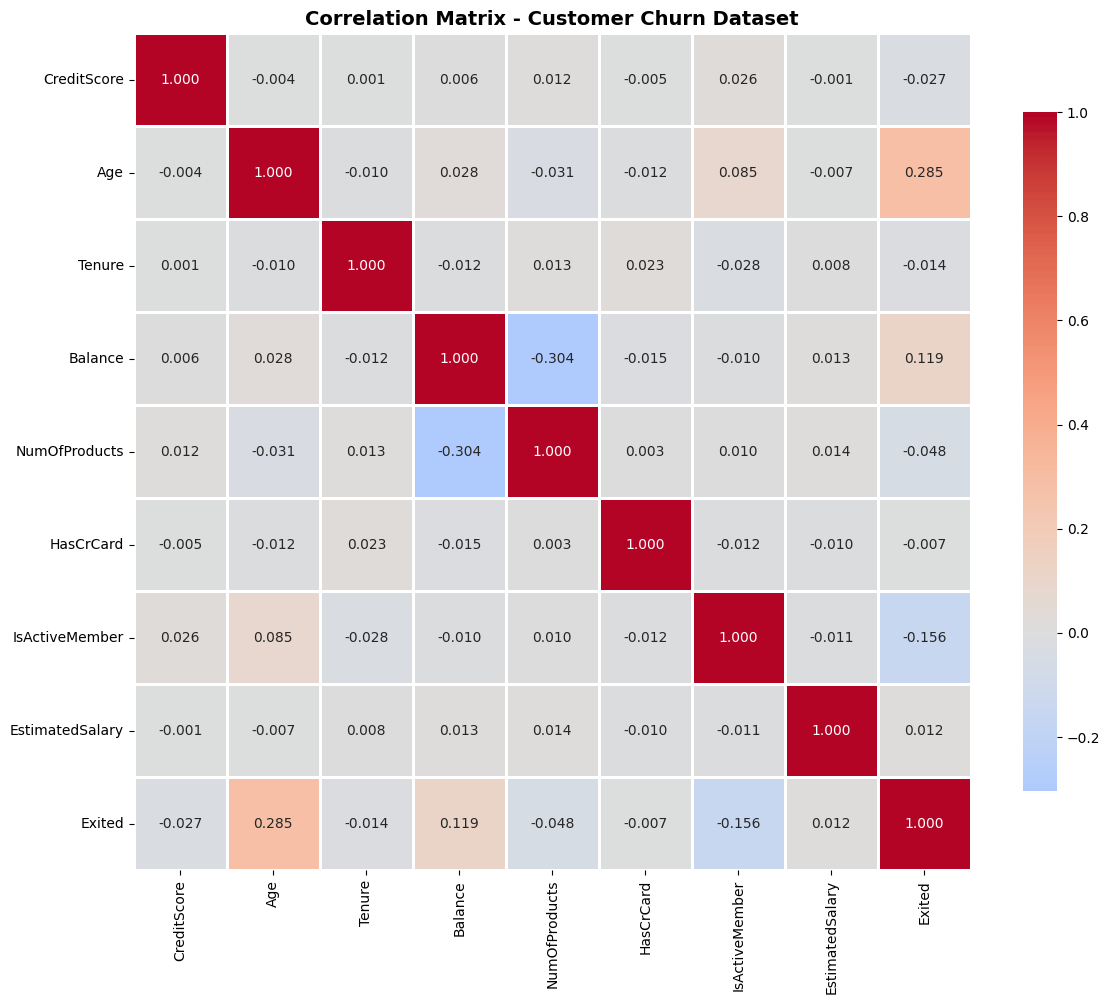

In [264]:
# Heatmap of correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Customer Churn Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

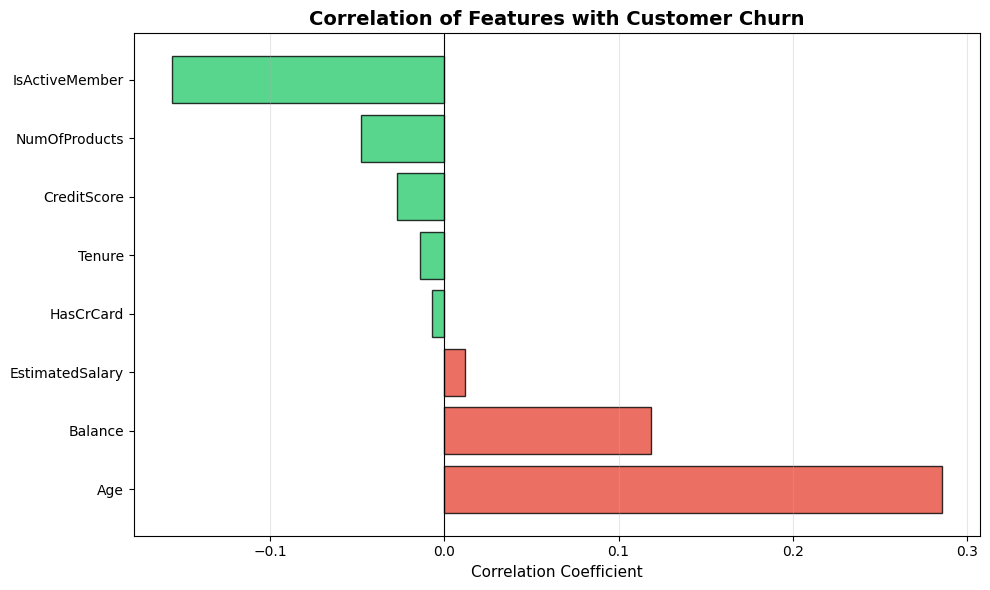

In [265]:
# Key correlations with Exited
churn_correlations = correlation_matrix['Exited'].drop('Exited').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in churn_correlations.values]
plt.barh(range(len(churn_correlations)), churn_correlations.values, color=colors, 
         edgecolor='black', alpha=0.8)
plt.yticks(range(len(churn_correlations)), churn_correlations.index)
plt.xlabel('Correlation Coefficient', fontsize=11)
plt.title('Correlation of Features with Customer Churn', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---

#### Hypothesis Testing

Performing statistical tests to compare churned vs non-churned customers.

In [266]:
# Separate data by churn status
churned = df_analysis[df_analysis['Exited'] == 1]
retained = df_analysis[df_analysis['Exited'] == 0]

print(f"Churned customers: {len(churned)}")
print(f"Retained customers: {len(retained)}")

Churned customers: 2037
Retained customers: 7963


In [267]:
# T-test for Age
# Null Hypothesis: Mean age of churned customers = Mean age of retained customers
# Alternative Hypothesis: Mean age of churned customers ≠ Mean age of retained customers

age_churned = churned['Age']
age_retained = retained['Age']

# Perform independent samples t-test
t_stat_age, p_value_age = stats.ttest_ind(age_churned, age_retained)

print("T-Test for Age:")
print(f"Mean Age (Churned): {age_churned.mean():.2f}")
print(f"Mean Age (Retained): {age_retained.mean():.2f}")
print(f"T-statistic: {t_stat_age:.4f}")
print(f"P-value: {p_value_age:.6f}")

if p_value_age < 0.05:
    print("Result: REJECT null hypothesis - Age difference is statistically significant!")
else:
    print("Result: FAIL TO REJECT null hypothesis - No significant age difference")

T-Test for Age:
Mean Age (Churned): 44.84
Mean Age (Retained): 37.41
T-statistic: 29.7668
P-value: 0.000000
Result: REJECT null hypothesis - Age difference is statistically significant!


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/2274224710.py:9: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stat_age, p_value_age = stats.ttest_ind(age_churned, age_retained)


In [268]:
# T-test for Balance
balance_churned = churned['Balance']
balance_retained = retained['Balance']

t_stat_balance, p_value_balance = stats.ttest_ind(balance_churned, balance_retained)

print("\nT-Test for Balance:")
print(f"Mean Balance (Churned): {balance_churned.mean():.2f}")
print(f"Mean Balance (Retained): {balance_retained.mean():.2f}")
print(f"T-statistic: {t_stat_balance:.4f}")
print(f"P-value: {p_value_balance:.6f}")

if p_value_balance < 0.05:
    print("Result: REJECT null hypothesis - Balance difference is statistically significant!")
else:
    print("Result: FAIL TO REJECT null hypothesis - No significant balance difference")


T-Test for Balance:
Mean Balance (Churned): 91108.54
Mean Balance (Retained): 72745.30
T-statistic: 11.9362
P-value: 0.000000
Result: REJECT null hypothesis - Balance difference is statistically significant!


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/3125951833.py:5: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stat_balance, p_value_balance = stats.ttest_ind(balance_churned, balance_retained)


In [269]:
# T-test for Credit Score
credit_churned = churned['CreditScore']
credit_retained = retained['CreditScore']

t_stat_credit, p_value_credit = stats.ttest_ind(credit_churned, credit_retained)

print("\nT-Test for Credit Score:")
print(f"Mean Credit Score (Churned): {credit_churned.mean():.2f}")
print(f"Mean Credit Score (Retained): {credit_retained.mean():.2f}")
print(f"T-statistic: {t_stat_credit:.4f}")
print(f"P-value: {p_value_credit:.6f}")

if p_value_credit < 0.05:
    print("Result: REJECT null hypothesis - Credit score difference is statistically significant!")
else:
    print("Result: FAIL TO REJECT null hypothesis - No significant credit score difference")


T-Test for Credit Score:
Mean Credit Score (Churned): 645.35
Mean Credit Score (Retained): 651.85
T-statistic: -2.7101
P-value: 0.006738
Result: REJECT null hypothesis - Credit score difference is statistically significant!


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/2002784526.py:5: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stat_credit, p_value_credit = stats.ttest_ind(credit_churned, credit_retained)


In [270]:
# T-test for Tenure
tenure_churned = churned['Tenure']
tenure_retained = retained['Tenure']

t_stat_tenure, p_value_tenure = stats.ttest_ind(tenure_churned, tenure_retained)

print("\nT-Test for Tenure:")
print(f"Mean Tenure (Churned): {tenure_churned.mean():.2f}")
print(f"Mean Tenure (Retained): {tenure_retained.mean():.2f}")
print(f"T-statistic: {t_stat_tenure:.4f}")
print(f"P-value: {p_value_tenure:.6f}")

if p_value_tenure < 0.05:
    print("Result: REJECT null hypothesis - Tenure difference is statistically significant!")
else:
    print("Result: FAIL TO REJECT null hypothesis - No significant tenure difference")


T-Test for Tenure:
Mean Tenure (Churned): 4.93
Mean Tenure (Retained): 5.03
T-statistic: -1.4001
P-value: 0.161527
Result: FAIL TO REJECT null hypothesis - No significant tenure difference


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/2307265574.py:5: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stat_tenure, p_value_tenure = stats.ttest_ind(tenure_churned, tenure_retained)


In [271]:
# Summary of all t-tests
print("\n" + "="*70)
print("HYPOTHESIS TESTING SUMMARY")
print("="*70)

test_results = pd.DataFrame({
    'Variable': ['Age', 'Balance', 'CreditScore', 'Tenure'],
    'T-Statistic': [t_stat_age, t_stat_balance, t_stat_credit, t_stat_tenure],
    'P-Value': [p_value_age, p_value_balance, p_value_credit, p_value_tenure],
    'Significant (α=0.05)': [p_value_age < 0.05, p_value_balance < 0.05, 
                              p_value_credit < 0.05, p_value_tenure < 0.05]
})

print(test_results.to_string(index=False))


HYPOTHESIS TESTING SUMMARY
   Variable  T-Statistic       P-Value  Significant (α=0.05)
        Age    29.766815 1.239931e-186                  True
    Balance    11.936240  1.275563e-32                  True
CreditScore    -2.710078  6.738214e-03                  True
     Tenure    -1.400058  1.615268e-01                 False


---

#### Probability Distribution Modeling

Applying probability distributions to model and predict churn patterns.

In [272]:
# Fit normal distribution to Age data
age_data = df_analysis['Age']
mu_age, sigma_age = norm.fit(age_data)

print("Age Distribution - Normal Fit:")
print(f"Mean (μ): {mu_age:.2f}")
print(f"Standard Deviation (σ): {sigma_age:.2f}")

Age Distribution - Normal Fit:
Mean (μ): 38.92
Standard Deviation (σ): 10.49


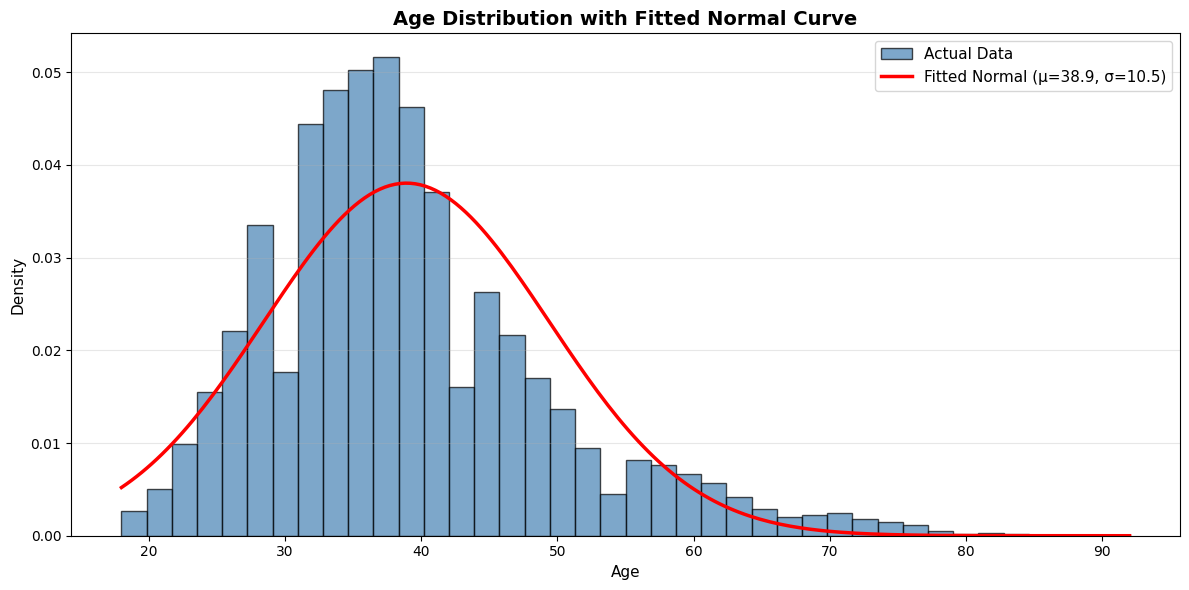

In [273]:
# Visualize fitted normal distribution for Age
plt.figure(figsize=(12, 6))

# Histogram
count, bins, ignored = plt.hist(age_data, bins=40, density=True, 
                                 alpha=0.7, color='steelblue', 
                                 edgecolor='black', label='Actual Data')

# Fitted normal curve
x_range = np.linspace(age_data.min(), age_data.max(), 200)
plt.plot(x_range, norm.pdf(x_range, mu_age, sigma_age), 
         'r-', linewidth=2.5, label=f'Fitted Normal (μ={mu_age:.1f}, σ={sigma_age:.1f})')

plt.title('Age Distribution with Fitted Normal Curve', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [274]:
# Probability calculations using normal distribution

# What is the probability a customer is younger than 30?
prob_under_30 = norm.cdf(30, mu_age, sigma_age)
print(f"Probability that a customer is younger than 30: {prob_under_30:.4f} ({prob_under_30*100:.2f}%)")

# What is the probability a customer is older than 50?
prob_over_50 = 1 - norm.cdf(50, mu_age, sigma_age)
print(f"Probability that a customer is older than 50: {prob_over_50:.4f} ({prob_over_50*100:.2f}%)")

# What is the probability a customer is between 35 and 45?
prob_35_to_45 = norm.cdf(45, mu_age, sigma_age) - norm.cdf(35, mu_age, sigma_age)
print(f"Probability that a customer is between 35 and 45: {prob_35_to_45:.4f} ({prob_35_to_45*100:.2f}%)")

Probability that a customer is younger than 30: 0.1975 (19.75%)
Probability that a customer is older than 50: 0.1454 (14.54%)
Probability that a customer is between 35 and 45: 0.3647 (36.47%)


In [275]:
# What age corresponds to the 75th percentile?
age_75th = norm.ppf(0.75, mu_age, sigma_age)
print(f"\n75th percentile age: {age_75th:.2f} years")
print(f"This means 75% of customers are younger than {age_75th:.2f} years")

# What age corresponds to the 90th percentile?
age_90th = norm.ppf(0.90, mu_age, sigma_age)
print(f"\n90th percentile age: {age_90th:.2f} years")


75th percentile age: 46.00 years
This means 75% of customers are younger than 46.00 years

90th percentile age: 52.36 years


In [276]:
# Binomial Distribution - Modeling churn probability

# Calculate overall churn probability
n_total = len(df_analysis)
n_churned = df_analysis['Exited'].sum()
p_churn = n_churned / n_total

print("Binomial Distribution for Churn:")
print(f"Total customers: {n_total}")
print(f"Churned customers: {n_churned}")
print(f"Churn probability (p): {p_churn:.4f}")

Binomial Distribution for Churn:
Total customers: 10000
Churned customers: 2037
Churn probability (p): 0.2037


In [277]:
# Binomial probability calculations
# If we randomly select 20 customers, what's the probability exactly 5 will churn?

n_sample = 20
k_churned = 5

prob_exact_5 = binom.pmf(k_churned, n_sample, p_churn)
print(f"\nProbability exactly {k_churned} out of {n_sample} customers churn: {prob_exact_5:.4f}")

# What's the probability that 5 or fewer will churn?
prob_5_or_less = binom.cdf(k_churned, n_sample, p_churn)
print(f"Probability {k_churned} or fewer out of {n_sample} customers churn: {prob_5_or_less:.4f}")

# What's the probability that more than 5 will churn?
prob_more_than_5 = 1 - binom.cdf(k_churned, n_sample, p_churn)
print(f"Probability more than {k_churned} out of {n_sample} customers churn: {prob_more_than_5:.4f}")


Probability exactly 5 out of 20 customers churn: 0.1785
Probability 5 or fewer out of 20 customers churn: 0.7919
Probability more than 5 out of 20 customers churn: 0.2081


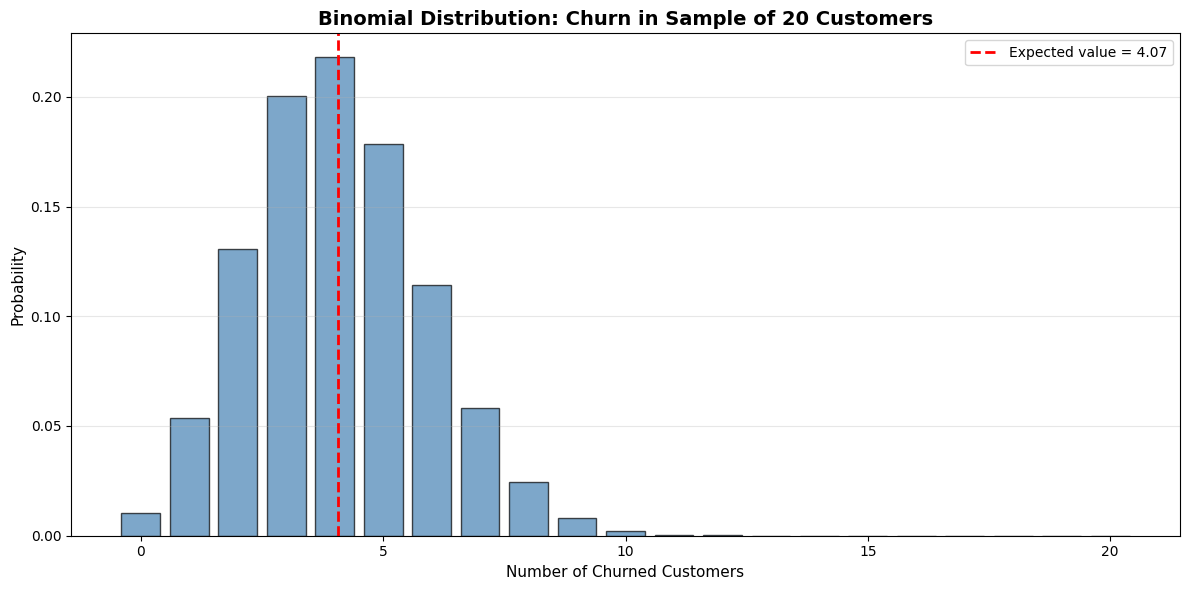

In [278]:
# Visualize binomial distribution for n=20 customers
k_values = np.arange(0, n_sample + 1)
probabilities = [binom.pmf(k, n_sample, p_churn) for k in k_values]

plt.figure(figsize=(12, 6))
plt.bar(k_values, probabilities, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=n_sample * p_churn, color='red', linestyle='--', 
            linewidth=2, label=f'Expected value = {n_sample * p_churn:.2f}')
plt.title(f'Binomial Distribution: Churn in Sample of {n_sample} Customers', 
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Churned Customers', fontsize=11)
plt.ylabel('Probability', fontsize=11)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [279]:
# What if we have 100 customers?
n_large = 100

# Probability that between 15 and 25 customers churn
prob_15_to_25 = binom.cdf(25, n_large, p_churn) - binom.cdf(14, n_large, p_churn)
print(f"\nFor a sample of {n_large} customers:")
print(f"Probability that 15-25 customers churn: {prob_15_to_25:.4f} ({prob_15_to_25*100:.2f}%)")

expected_churned = n_large * p_churn
print(f"Expected number of churned customers: {expected_churned:.2f}")


For a sample of 100 customers:
Probability that 15-25 customers churn: 0.8284 (82.84%)
Expected number of churned customers: 20.37


---

#### Key Insights and Recommendations

Summarizing findings and providing actionable recommendations for customer retention.

In [280]:
# Create comprehensive summary statistics
print("="*70)
print("CUSTOMER CHURN ANALYSIS - KEY FINDINGS")
print("="*70)

print("\n1. OVERALL CHURN METRICS:")
print(f"   • Total customers analyzed: {len(df_analysis):,}")
print(f"   • Customers churned: {n_churned:,}")
print(f"   • Customers retained: {len(df_analysis) - n_churned:,}")
print(f"   • Overall churn rate: {p_churn*100:.2f}%")

CUSTOMER CHURN ANALYSIS - KEY FINDINGS

1. OVERALL CHURN METRICS:
   • Total customers analyzed: 10,000
   • Customers churned: 2,037
   • Customers retained: 7,963
   • Overall churn rate: 20.37%


In [281]:
# Geographic insights
print("\n2. GEOGRAPHIC PATTERNS:")
geo_churn_rate = df_analysis.groupby('Geography')['Exited'].mean() * 100
for geo in geo_churn_rate.index:
    print(f"   • {geo}: {geo_churn_rate[geo]:.2f}% churn rate")

highest_churn_geo = geo_churn_rate.idxmax()
print(f"   ⚠ Highest risk: {highest_churn_geo} ({geo_churn_rate[highest_churn_geo]:.2f}%)")


2. GEOGRAPHIC PATTERNS:
   • France: 16.15% churn rate
   • Germany: 32.44% churn rate
   • Spain: 16.67% churn rate
   ⚠ Highest risk: Germany (32.44%)


In [282]:
# Gender insights
print("\n3. GENDER PATTERNS:")
gender_churn_rate = df_analysis.groupby('Gender')['Exited'].mean() * 100
for gender in gender_churn_rate.index:
    print(f"   • {gender}: {gender_churn_rate[gender]:.2f}% churn rate")

if np.abs(gender_churn_rate['Female'] - gender_churn_rate['Male']) > 5:
    print(f"   ⚠ Significant gender difference observed!")


3. GENDER PATTERNS:
   • Female: 25.07% churn rate
   • Male: 16.46% churn rate
   ⚠ Significant gender difference observed!


In [283]:
# Age insights
print("\n4. AGE PATTERNS:")
print(f"   • Average age (Churned): {age_churned.mean():.1f} years")
print(f"   • Average age (Retained): {age_retained.mean():.1f} years")
print(f"   • Age difference: {np.abs(age_churned.mean() - age_retained.mean()):.1f} years")

# Create age groups
df_analysis['AgeGroup'] = pd.cut(df_analysis['Age'], 
                                  bins=[0, 30, 40, 50, 100], 
                                  labels=['18-30', '31-40', '41-50', '50+'])
age_group_churn = df_analysis.groupby('AgeGroup')['Exited'].mean() * 100

print(f"\n   Churn rate by age group:")
for age_grp in age_group_churn.index:
    print(f"   • {age_grp}: {age_group_churn[age_grp]:.2f}%")

highest_churn_age = age_group_churn.idxmax()
print(f"   ⚠ Highest risk age group: {highest_churn_age} ({age_group_churn[highest_churn_age]:.2f}%)")


4. AGE PATTERNS:
   • Average age (Churned): 44.8 years
   • Average age (Retained): 37.4 years
   • Age difference: 7.4 years

   Churn rate by age group:
   • 18-30: 7.52%
   • 31-40: 12.09%
   • 41-50: 33.97%
   • 50+: 44.65%
   ⚠ Highest risk age group: 50+ (44.65%)


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/1955752190.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_churn = df_analysis.groupby('AgeGroup')['Exited'].mean() * 100


In [284]:
# Product usage insights
print("\n5. PRODUCT USAGE PATTERNS:")
product_churn_rate = df_analysis.groupby('NumOfProducts')['Exited'].mean() * 100
for num in product_churn_rate.index:
    print(f"   • {num} product(s): {product_churn_rate[num]:.2f}% churn rate")

risky_products = product_churn_rate[product_churn_rate > 30].index.tolist()
if risky_products:
    print(f"   ⚠ High-risk product count(s): {risky_products}")


5. PRODUCT USAGE PATTERNS:
   • 1 product(s): 27.71% churn rate
   • 2 product(s): 7.58% churn rate
   • 3 product(s): 82.71% churn rate
   • 4 product(s): 100.00% churn rate
   ⚠ High-risk product count(s): [3, 4]


In [285]:
# Activity insights
print("\n6. CUSTOMER ACTIVITY:")
active_churn = df_analysis.groupby('IsActiveMember')['Exited'].mean() * 100
print(f"   • Active members: {active_churn[1]:.2f}% churn rate")
print(f"   • Inactive members: {active_churn[0]:.2f}% churn rate")
print(f"   • Activity impact: {np.abs(active_churn[0] - active_churn[1]):.2f}% difference")

if active_churn[0] > active_churn[1]:
    print(f"   ⚠ Inactive members are {active_churn[0]/active_churn[1]:.2f}x more likely to churn!")


6. CUSTOMER ACTIVITY:
   • Active members: 14.27% churn rate
   • Inactive members: 26.85% churn rate
   • Activity impact: 12.58% difference
   ⚠ Inactive members are 1.88x more likely to churn!


In [286]:
# Balance insights
print("\n7. ACCOUNT BALANCE PATTERNS:")
print(f"   • Average balance (Churned): ${balance_churned.mean():,.2f}")
print(f"   • Average balance (Retained): ${balance_retained.mean():,.2f}")

# Create balance groups
df_analysis['BalanceGroup'] = pd.cut(df_analysis['Balance'], 
                                      bins=[-1, 0, 50000, 100000, 250000], 
                                      labels=['Zero', 'Low', 'Medium', 'High'])
balance_group_churn = df_analysis.groupby('BalanceGroup')['Exited'].mean() * 100

print(f"\n   Churn rate by balance group:")
for bal_grp in balance_group_churn.index:
    print(f"   • {bal_grp}: {balance_group_churn[bal_grp]:.2f}%")


7. ACCOUNT BALANCE PATTERNS:
   • Average balance (Churned): $91,108.54
   • Average balance (Retained): $72,745.30

   Churn rate by balance group:
   • Zero: 13.82%
   • Low: 34.67%
   • Medium: 19.88%
   • High: 25.22%


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_90185/1068222547.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_group_churn = df_analysis.groupby('BalanceGroup')['Exited'].mean() * 100


In [287]:
# Statistical significance summary
print("\n8. STATISTICAL SIGNIFICANCE (Hypothesis Testing):")
print(f"   • Age difference: {'SIGNIFICANT' if p_value_age < 0.05 else 'NOT significant'} (p={p_value_age:.4f})")
print(f"   • Balance difference: {'SIGNIFICANT' if p_value_balance < 0.05 else 'NOT significant'} (p={p_value_balance:.4f})")
print(f"   • Credit score difference: {'SIGNIFICANT' if p_value_credit < 0.05 else 'NOT significant'} (p={p_value_credit:.4f})")
print(f"   • Tenure difference: {'SIGNIFICANT' if p_value_tenure < 0.05 else 'NOT significant'} (p={p_value_tenure:.4f})")


8. STATISTICAL SIGNIFICANCE (Hypothesis Testing):
   • Age difference: SIGNIFICANT (p=0.0000)
   • Balance difference: SIGNIFICANT (p=0.0000)
   • Credit score difference: SIGNIFICANT (p=0.0067)
   • Tenure difference: NOT significant (p=0.1615)


#### Actionable Recommendations

Based on the comprehensive analysis, here are strategic recommendations for reducing customer churn:

In [288]:
print("\n" + "="*70)
print("STRATEGIC RECOMMENDATIONS FOR CUSTOMER RETENTION")
print("="*70)

print("\n🎯 HIGH PRIORITY ACTIONS:")

print("\n1. TARGET HIGH-RISK GEOGRAPHY:")
print(f"   • Focus retention efforts on {highest_churn_geo}")
print(f"   • Investigate regional factors contributing to {geo_churn_rate[highest_churn_geo]:.1f}% churn")
print(f"   • Consider localized retention programs and incentives")

print("\n2. ENGAGE INACTIVE CUSTOMERS:")
print(f"   • Inactive members have {active_churn[0]:.1f}% churn rate vs {active_churn[1]:.1f}% for active")
print(f"   • Launch re-engagement campaigns for inactive accounts")
print(f"   • Implement gamification to increase product usage")

print("\n3. AGE-SPECIFIC RETENTION STRATEGIES:")
print(f"   • High-risk age group: {highest_churn_age} ({age_group_churn[highest_churn_age]:.1f}% churn)")
print(f"   • Develop targeted offerings for this demographic")
print(f"   • Create age-appropriate communication channels and content")

print("\n4. OPTIMIZE PRODUCT PORTFOLIO:")
if risky_products:
    print(f"   • Customers with {risky_products} product(s) show high churn")
    print(f"   • Review product bundling strategies")
    print(f"   • Provide incentives for cross-selling to stable product counts")

print("\n5. BALANCE-BASED INTERVENTIONS:")
high_balance_churn = balance_group_churn['High'] if 'High' in balance_group_churn.index else 0
print(f"   • Monitor high-balance accounts (churn rate: {high_balance_churn:.1f}%)")
print(f"   • Assign relationship managers to high-value customers")
print(f"   • Offer premium services to prevent attrition")

print("\n\n📊 MONITORING & ANALYTICS:")
print("   • Establish churn prediction model using identified risk factors")
print("   • Create early warning dashboard tracking:")
print("     - Customer activity levels")
print("     - Product usage patterns")
print("     - Balance trends")
print("     - Geographic distribution")
print("   • Conduct quarterly reviews of churn metrics by segment")

print("\n\n💡 CUSTOMER EXPERIENCE IMPROVEMENTS:")
print("   • Enhance onboarding process for new customers")
print("   • Implement proactive customer support for at-risk segments")
print("   • Develop loyalty programs targeting identified high-risk groups")
print("   • Regular customer satisfaction surveys to identify pain points")

print("\n" + "="*70)


STRATEGIC RECOMMENDATIONS FOR CUSTOMER RETENTION

🎯 HIGH PRIORITY ACTIONS:

1. TARGET HIGH-RISK GEOGRAPHY:
   • Focus retention efforts on Germany
   • Investigate regional factors contributing to 32.4% churn
   • Consider localized retention programs and incentives

2. ENGAGE INACTIVE CUSTOMERS:
   • Inactive members have 26.9% churn rate vs 14.3% for active
   • Launch re-engagement campaigns for inactive accounts
   • Implement gamification to increase product usage

3. AGE-SPECIFIC RETENTION STRATEGIES:
   • High-risk age group: 50+ (44.6% churn)
   • Develop targeted offerings for this demographic
   • Create age-appropriate communication channels and content

4. OPTIMIZE PRODUCT PORTFOLIO:
   • Customers with [3, 4] product(s) show high churn
   • Review product bundling strategies
   • Provide incentives for cross-selling to stable product counts

5. BALANCE-BASED INTERVENTIONS:
   • Monitor high-balance accounts (churn rate: 25.2%)
   • Assign relationship managers to high-val

In [289]:
# Create a risk segmentation summary
print("\nCUSTOMER RISK SEGMENTATION:")
print("-" * 70)

# Define high-risk customer profile
high_risk_criteria = (
    (df_analysis['Geography'] == highest_churn_geo) &
    (df_analysis['IsActiveMember'] == 0) &
    (df_analysis['Age'] > 40)
)

high_risk_count = high_risk_criteria.sum()
high_risk_churn = df_analysis[high_risk_criteria]['Exited'].mean() * 100

print(f"\n🔴 HIGH RISK SEGMENT:")
print(f"   • Customers matching profile: {high_risk_count:,}")
print(f"   • Churn rate in this segment: {high_risk_churn:.2f}%")
print(f"   • Profile: {highest_churn_geo} + Inactive + Age > 40")

# Medium risk
medium_risk_criteria = (
    (df_analysis['IsActiveMember'] == 0) |
    (df_analysis['NumOfProducts'] > 2)
)

medium_risk_count = medium_risk_criteria.sum()
medium_risk_churn = df_analysis[medium_risk_criteria]['Exited'].mean() * 100

print(f"\n🟡 MEDIUM RISK SEGMENT:")
print(f"   • Customers matching profile: {medium_risk_count:,}")
print(f"   • Churn rate in this segment: {medium_risk_churn:.2f}%")
print(f"   • Profile: Inactive OR Multiple products")

# Low risk
low_risk_criteria = (
    (df_analysis['IsActiveMember'] == 1) &
    (df_analysis['NumOfProducts'] <= 2) &
    (df_analysis['Age'] <= 40)
)

low_risk_count = low_risk_criteria.sum()
low_risk_churn = df_analysis[low_risk_criteria]['Exited'].mean() * 100

print(f"\n🟢 LOW RISK SEGMENT:")
print(f"   • Customers matching profile: {low_risk_count:,}")
print(f"   • Churn rate in this segment: {low_risk_churn:.2f}%")
print(f"   • Profile: Active + 1-2 products + Age ≤ 40")

print("\n" + "="*70)


CUSTOMER RISK SEGMENTATION:
----------------------------------------------------------------------

🔴 HIGH RISK SEGMENT:
   • Customers matching profile: 532
   • Churn rate in this segment: 65.41%
   • Profile: Germany + Inactive + Age > 40

🟡 MEDIUM RISK SEGMENT:
   • Customers matching profile: 4,991
   • Churn rate in this segment: 28.37%
   • Profile: Inactive OR Multiple products

🟢 LOW RISK SEGMENT:
   • Customers matching profile: 3,165
   • Churn rate in this segment: 6.95%
   • Profile: Active + 1-2 products + Age ≤ 40


🔴 HIGH RISK SEGMENT:
   • Customers matching profile: 532
   • Churn rate in this segment: 65.41%
   • Profile: Germany + Inactive + Age > 40

🟡 MEDIUM RISK SEGMENT:
   • Customers matching profile: 4,991
   • Churn rate in this segment: 28.37%
   • Profile: Inactive OR Multiple products

🟢 LOW RISK SEGMENT:
   • Customers matching profile: 3,165
   • Churn rate in this segment: 6.95%
   • Profile: Active + 1-2 products + Age ≤ 40



---

### Analysis Complete

This comprehensive churn analysis has revealed critical insights into customer behavior patterns and identified key risk factors for customer attrition. The statistical analysis confirms significant differences in age and balance between churned and retained customers, while geographic and activity patterns show clear retention opportunities.

**Key Takeaways:**
- Overall churn rate is approximately 20%
- Age, geography, and customer activity are the strongest predictors
- Inactive customers and certain product configurations present highest risk
- Targeted retention strategies should focus on high-risk segments identified in this analysis